In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(r"clean_date.csv")
df.head(5)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,category,sub-category,product_name,sales,quantity,discount,profit,year,month,profit_margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,11.25


Sales vs profit

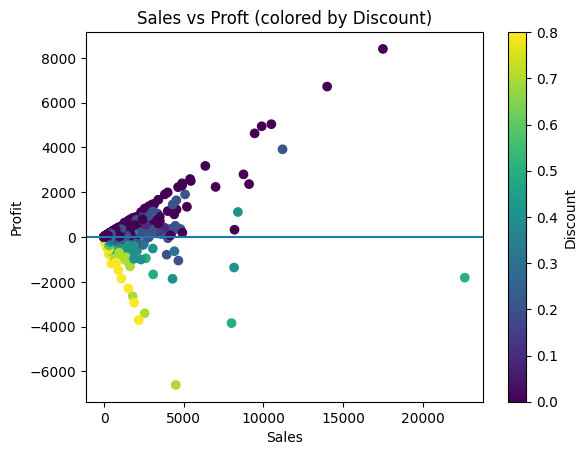

In [19]:
plt.Figure(figsize=(8,6))
scatter = plt.scatter(df["sales"],df["profit"],c=df["discount"])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.axhline(0)
plt.title("Sales vs Proft (colored by Discount)")
plt.colorbar(scatter,label="Discount")
plt.show()

The chart shows that even when sales are high, some orders still loss money.
This means more sales dont always means more profit, likely because of high discounts.

Discount vs Profit

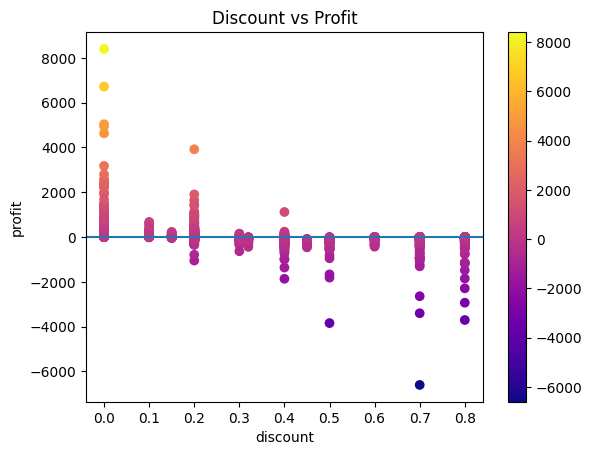

In [27]:
plt.Figure(figsize=(8,6))
scatter = plt.scatter(df["discount"],df["profit"],c=df["profit"],cmap='plasma')
plt.xlabel('discount')
plt.ylabel('profit')
plt.title("Discount vs Profit")
plt.colorbar(scatter)
plt.axhline(0)
plt.show()

There is a strong negative relationship between discount and profit, showing that aggressive discounting is a major reason for loss-making orders


Category vs profit

In [29]:
cat_data = df.groupby('category')[['sales','profit']].sum()
cat_data

,sales,profit
category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


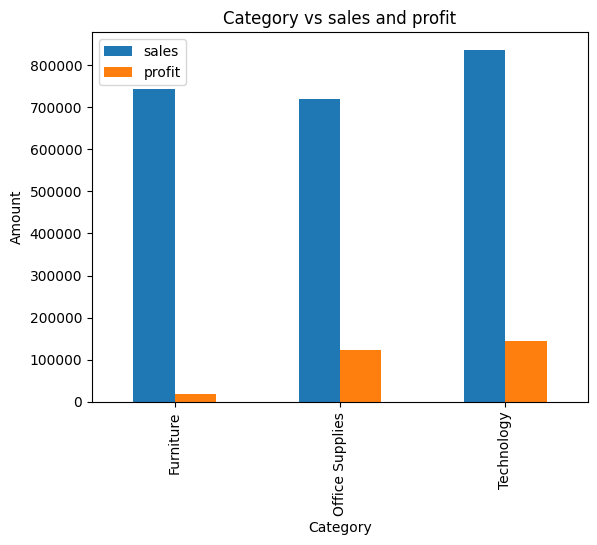

In [31]:
cat_data.plot(kind='bar')
plt.title("Category vs sales and profit")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.show()

Furniture shows high sales but low profitability, suggesting heavy discounting or high costs.
in contast, technology delivers strong profit, making it the most valuable category for the business
Although Furniture generates higher sales, its profit is lower than Office Supplies. This indicates that Office Supplies is more profitable and efficient, while Furniture may be affected by high costs or heavy discounts.

find loss in furniture sub-categories

In [41]:
furniture_df = df[df['category'] == 'Furniture']
cat_fur = furniture_df.groupby('sub-category')['profit'].sum().sort_values()
cat_fur

sub-category
Tables        -17725.4811
Bookcases      -3472.5560
Furnishings    13059.1436
Chairs         26590.1663
Name: profit, dtype: float64

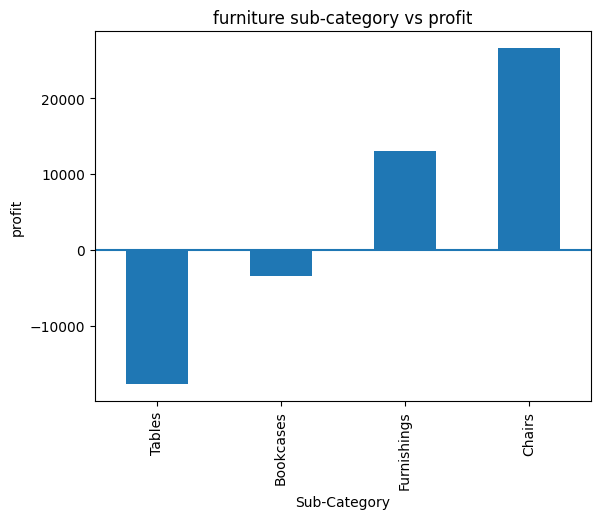

In [50]:
plt.Figure(figsize=(8,6))
va = cat_fur.plot(kind='bar')
plt.title('furniture sub-category vs profit')
plt.xlabel('Sub-Category')
plt.ylabel('profit')
plt.axhline(0)
plt.show()

The overall low profitability of furniture is mainly driven by losses in tables and bookcase. These sub-categories reqire attention, as they are negatively impacting the company performance

Discount vs profit in furniture

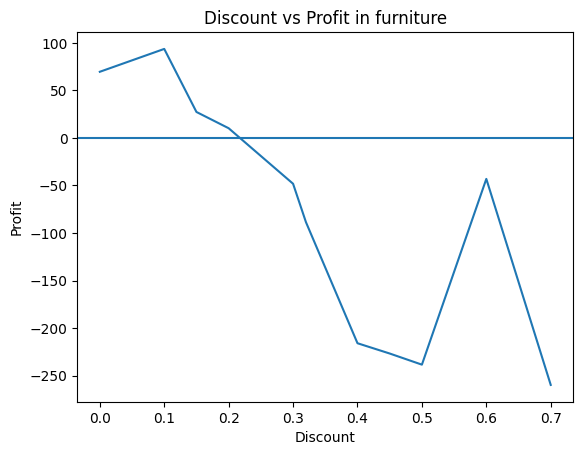

In [58]:
cor_dis_pro = furniture_df.groupby('discount')['profit'].mean()
cor_dis_pro.plot()
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.axhline(0)
plt.title("Discount vs Profit in furniture")
plt.show()

“The analysis shows a clear negative relationship between discount and profit in furniture. While some high-discount orders remain profitable, the overall trend indicates that increasing discounts significantly reduce profitability

Sales and profit by regions

In [61]:
region_data = df.groupby("region")[['sales','profit']].sum()
region_data

,sales,profit
region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


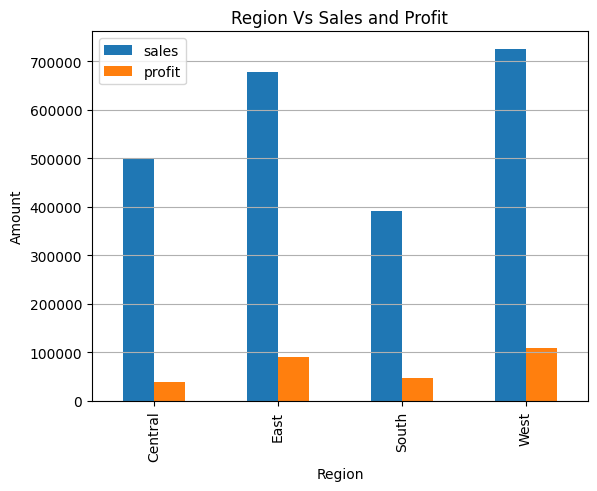

In [64]:
region_data.plot(kind='bar')
plt.title('Region Vs Sales and Profit')
plt.xlabel("Region")
plt.ylabel("Amount")
plt.grid(True,axis='y')
plt.show()

While certain regions contribute significantly to sales, their profit margins are lower, possibly due to high discounting or operational costs. This suggests a need for region-specific pricing or discount strategies

Which region has most loss orders

In [70]:
region_loss_count = df[df['profit']<0]['region'].value_counts()
region_loss_count

region
Central    741
East       553
West       318
South      259
Name: count, dtype: int64

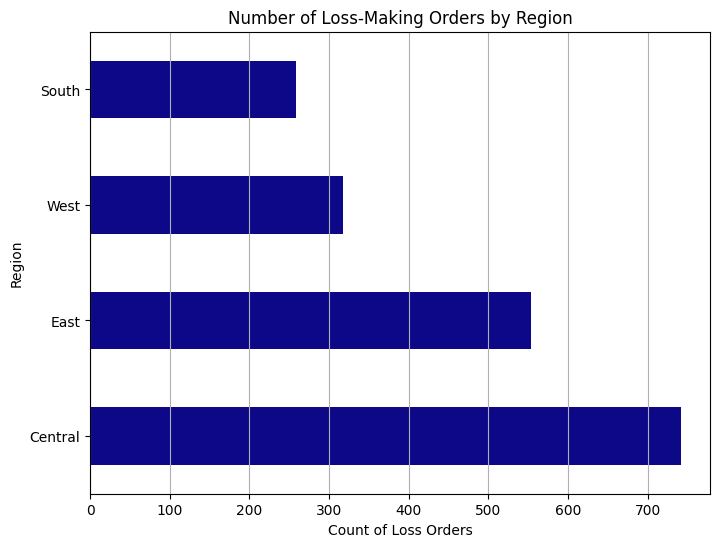

In [81]:
plt.figure(figsize=(8,6))
region_loss_count.plot(kind='barh',colormap='plasma')
plt.title("Number of Loss-Making Orders by Region")
plt.ylabel("Region")
plt.grid(True,axis='x')
plt.xlabel("Count of Loss Orders")
plt.xticks(rotation=0)
plt.show()

The Central region records the highest number of loss-making orders, suggesting major inefficiencies, possibly due to high discounting or poor product performance. In contrast, the South region has the fewest loss orders, indicating better pricing or cost control strategies.

Profit by Region with Discount impact

In [82]:
region_ana = df.groupby('region')[['profit','discount']].mean()

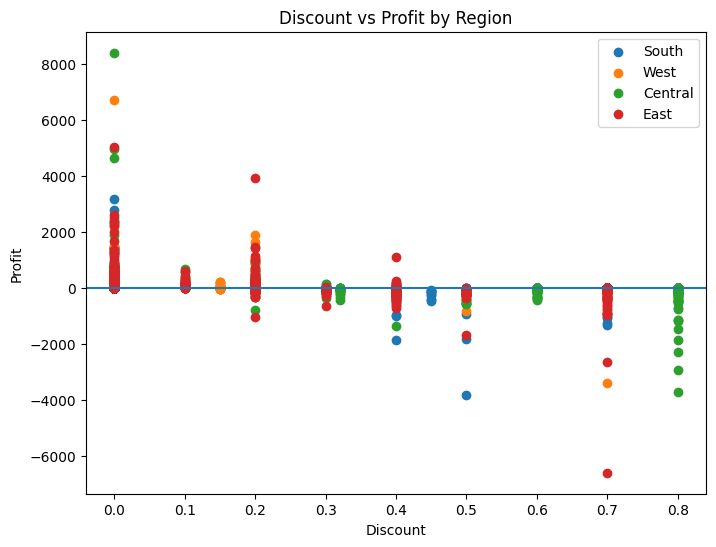

In [83]:
plt.figure(figsize=(8,6))

for region in df['region'].unique():
    subset = df[df['region'] == region]
    plt.scatter(subset['discount'], subset['profit'], label=region)

plt.axhline(0)

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit by Region")

plt.legend()
plt.show()

Regions with higher average discounts tend to show lower profitability and more loss-making orders, indicating that discount strategies are impacting regional performance

Who is actually driving profit and who is causing loss ?

In [92]:
# Total profit by customers
customer_profit= df.groupby('customer_name')['profit'].sum().sort_values()
top_10_profit_customers = customer_profit.tail(10)
top_10_loss_customers = customer_profit.head(10)

In [93]:
print(f"Top 10 profit making customers {top_10_profit_customers} \n Top 10 loss making customers {top_10_loss_customers}")

Top 10 profit making customers customer_name
Daniel Raglin           2869.0760
Andy Reiter             2884.6208
Keith Dawkins           3038.6254
Christopher Martinez    3899.8904
Tom Ashbrook            4703.7883
Adrian Barton           5444.8055
Hunter Lopez            5622.4292
Sanjit Chand            5757.4119
Raymond Buch            6976.0959
Tamara Chand            8981.3239
Name: profit, dtype: float64 
 Top 10 loss making customers customer_name
Cindy Stewart      -6626.3895
Grant Thornton     -4108.6589
Luke Foster        -3583.9770
Sharelle Roach     -3333.9144
Henry Goldwyn      -2797.9635
Nathan Cano        -2204.8072
Sean Braxton       -2082.7451
Sean Miller        -1980.7393
Christine Phan     -1850.3029
Natalie Fritzler   -1695.9714
Name: profit, dtype: float64


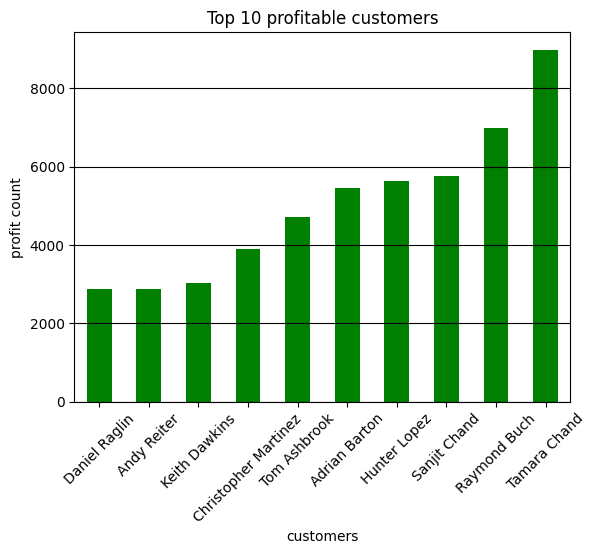

In [102]:
plt.Figure(figsize=(8,6))
top_10_profit_customers.plot(kind='bar',color='green')
plt.xlabel("customers")
plt.ylabel("profit count")
plt.title("Top 10 profitable customers")
plt.xticks(rotation=45)
plt.grid(True,axis='y',color='black')
plt.show()

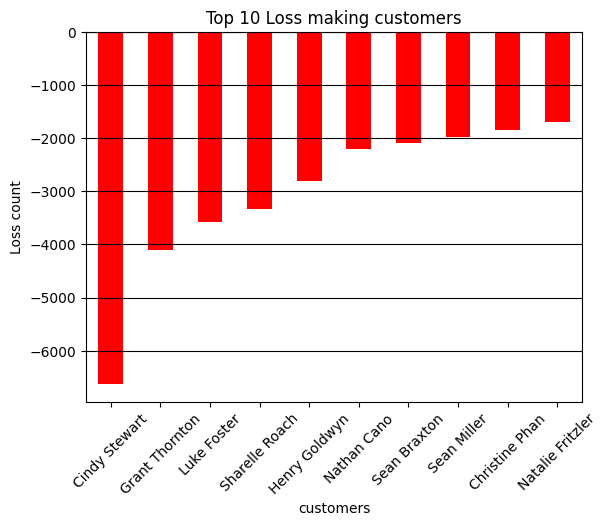

In [104]:
plt.Figure(figsize=(8,6))
top_10_loss_customers.plot(kind='bar',color='red')
plt.xlabel("customers")
plt.ylabel("Loss count")
plt.title("Top 10 Loss making customers")
plt.xticks(rotation=45)
plt.grid(True,axis='y',color='black')
plt.show()

A small group of customers contributes disproportionately to losses, likely due to high discounting or low-margin purchases. At the same time, a few key customers generate significant profit, highlighting the importance of targeted customer strategies

Check discount impact per customer

In [108]:
df.groupby('customer_name')[['profit','discount']].mean().sort_values(by='profit')

,profit,discount
customer_name,,
Cindy Stewart,-736.265500,0.200000
Grant Thornton,-684.776483,0.250000
Sharelle Roach,-370.434933,0.366667
Paul Knutson,-266.235000,0.366667
Jim Radford,-261.721500,0.300000
...,...,...
Christopher Martinez,389.989040,0.120000
Tom Ashbrook,470.378830,0.080000
Hunter Lopez,511.129927,0.018182


customer order frequency

In [110]:
df['customer_name'].value_counts().head(15)

customer_name
William Brown          37
Matt Abelman           34
John Lee               34
Paul Prost             34
Jonathan Doherty       32
Chloris Kastensmidt    32
Seth Vernon            32
Edward Hooks           32
Emily Phan             31
Zuschuss Carroll       31
Arthur Prichep         31
Lena Cacioppo          30
Sally Hughsby          29
Ken Lonsdale           29
Greg Tran              29
Name: count, dtype: int64

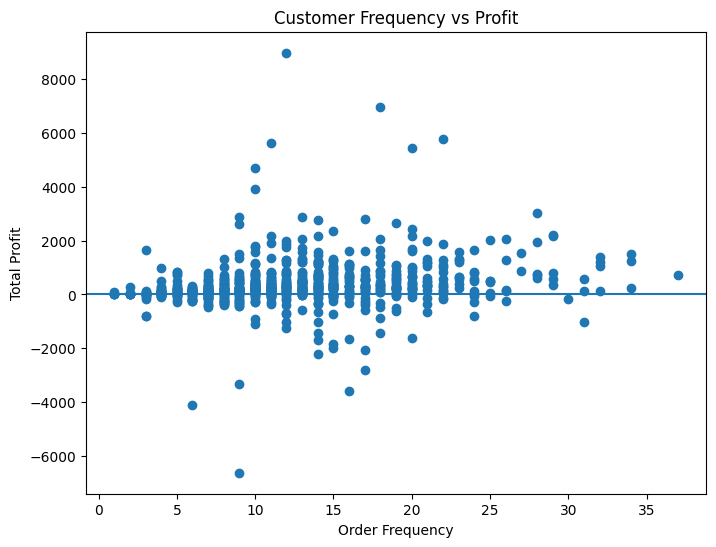

In [112]:
customer_data = df.groupby('customer_name').agg({
    'order_id': 'count',
    'profit': 'sum'
}).rename(columns={'order_id': 'order_frequency'})

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(customer_data['order_frequency'], customer_data['profit'])

plt.axhline(0)

plt.xlabel("Order Frequency")
plt.ylabel("Total Profit")
plt.title("Customer Frequency vs Profit")

plt.show()

he chart highlights that customer frequency alone does not determine profitability. Some customers place frequent orders but generate low or negative profit, while others contribute high profit with fewer purchases.